In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import csv
import cv2

In [2]:
steering_test = pd.read_csv('../../testdata/driving_log.csv', sep=';')
steering_train = pd.read_csv('../../traindata/driving_log.csv', sep=';')


In [28]:
steer_data = steering_test['Steering'].values
steer_data2 = steering_train['Steering'].values


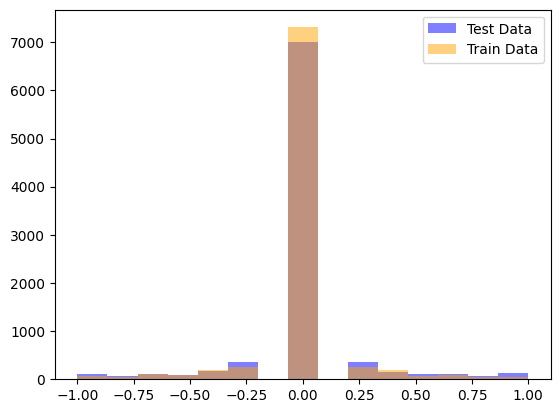

In [35]:
r =plt.hist(steer_data, bins=15, alpha=0.5, label='Test Data', color='blue')

t =plt.hist(steer_data2, bins=15, alpha=0.5, label='Train Data', color='orange')

plt.legend(loc='upper right')

In [ ]:
import os
import random
import uuid
from pathlib import Path



# Use only the training data for augmentation
df_train = steering_train.copy()

df_train['Imgs'] = df_train['Imgs'].str.replace('C:\\Users\\Tune and Tones\\Documents\\traindata\\IMG\\', '').copy()


# Randomly augment only a portion of the training set
augment_fraction = 0.25
sample_size = max(1, int(len(df_train) * augment_fraction))
sample_idx = np.random.choice(df_train.index, size=sample_size, replace=False)

output_dir = Path("../../augmented_train_data")
output_dir.mkdir(parents=True, exist_ok=True)

def augment_image(img_path, steering_angle):
    
    img = cv2.imread(img_path);
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if img is None:
        raise FileNotFoundError(f"Could not open or find the image at: {img_path}")
    

    # 1) Horizontal flip -> reverse steering angle
    if random.random() < 0.5:
        img = cv2.flip(img, 1)  # Horizontal flip
        steering_angle *= -1.0

    # 2) Brightness adjustment (cv2)
    if random.random() < 0.5:
        brightness = random.uniform(0.7, 1.3)

        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[..., 2] = np.clip(hsv[..., 2] * brightness, 0, 255)
        img = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

    # 3) Zoom / crop (simulate zooming and panning)
    if random.random() < 0.5:
        crop_w = int(w * random.uniform(0.85, 1.0))
        crop_h = int(h * random.uniform(0.85, 1.0))
        left = random.randint(0, max(0, w - crop_w))
        top = random.randint(0, max(0, h - crop_h))

        img = img[top:top + crop_h, left:left + crop_w]
        img = cv2.resize(img, (w, h), interpolation=cv2.INTER_CUBIC)

    # 4) Rotation (cv2)
    if random.random() < 0.5:
        rotation_deg = random.uniform(-15, 15)
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, rotation_deg, 1.0)
        cos = np.abs(M[0, 0])
        sin = np.abs(M[0, 1])
        new_w = int((h * sin) + (w * cos))
        new_h = int((h * cos) + (w * sin))
        M[0, 2] += (new_w / 2) - center[0]
        M[1, 2] += (new_h / 2) - center[1]
        img = cv2.warpAffine(
            img,
            M,
            (new_w, new_h),
            flags=cv2.INTER_CUBIC,
            borderMode=cv2.BORDER_REPLICATE
        )

    # Write augmented image to disk
    out_path = output_dir / f"{uuid.uuid4().hex}.png"
    cv2.imwrite(str(out_path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    return str(out_path), steering_angle

augmented_rows = []
IMAGE_DIR = "../traindata/IMG"
for idx in sample_idx:
    row = df_train.loc[idx]
    full_img_path = os.path.join(IMAGE_DIR, row["Imgs"])
    aug_img_path, aug_angle = augment_image(full_img_path, float(row["Steering"]))
    augmented_rows.append({"Imgs": aug_img_path, "Steering": aug_angle})

steering_train_augmented = pd.DataFrame(augmented_rows, columns=["Imgs", "Steering"])


steering_train_augmented = pd.concat(
    [df_train, steering_train_augmented],
    ignore_index=True
)

steering_train_augmented.head()

,Imgs,Steering
0,center_2026_08_02_18_56_16_590.jpg,-0.45
1,center_2026_08_02_18_56_16_680.jpg,0.00
2,center_2026_08_02_18_56_16_763.jpg,0.00
3,center_2026_08_02_18_56_16_845.jpg,0.00
4,center_2026_08_02_18_56_16_930.jpg,0.00


In [ ]:
def preprocess_frame(frame, target_size=(200, 66)):
    """
    Preprocess a driving image for the NVIDIA CNN:
    1) Crop the road region
    2) Convert to YUV
    3) Apply Gaussian blur
    4) Resize to 200x66
    5) Normalize
    """
    if frame is None:
        raise ValueError("Image could not be loaded.")

    h, w = frame.shape[:2]

    # Crop the lower portion of the image to focus on the road
    cropped = frame[int(h * 0.35):int(h * 0.97), int(w * 0.05):int(w * 0.95)]

    # Convert to YUV color space
    yuv = cv2.cvtColor(cropped, cv2.COLOR_BGR2YUV)

    # Apply Gaussian blur
    blurred = cv2.GaussianBlur(yuv, (3, 3), 0)

    # Resize to NVIDIA model input size
    resized = cv2.resize(blurred, target_size, interpolation=cv2.INTER_AREA)

    # Normalize to approximately [-0.5, 0.5]
    resized = resized.astype(np.float32) / 255.0 - 0.5

    return resized


# Example usage with a sample training image
sample_path = os.path.join(IMAGE_DIR, df_train['Imgs'].iloc[0])
sample_img = cv2.imread(sample_path)

if sample_img is None:
    raise FileNotFoundError(f"Could not read sample image: {sample_path}")

processed_img = preprocess_frame(sample_img)
cv2.imshow('Processed Image', (processed_img )  ) 
cv2.waitKey(0)
cv2.destroyAllWindows()

print("Processed image shape:", processed_img.shape)
print("Processed image dtype:", processed_img.dtype)
print("Value range:", processed_img.min(), processed_img.max())

Processed image shape: (66, 200, 3)
Processed image dtype: float32
Value range: -0.35490197 0.49215686


In [41]:
def batch_dataset(data_frame, batch_size=32, shuffle=False, image_dir=IMAGE_DIR):
    """
    Generate batches of preprocessed driving images and steering angles.

    Parameters:
        data_frame (pd.DataFrame): DataFrame with columns ['Imgs', 'Steering']
        batch_size (int): Number of samples per batch
        shuffle (bool): Shuffle the samples before batching
        image_dir (str): Root directory containing image files

    Yields:
        (np.ndarray, np.ndarray): batch of images and corresponding steering angles
    """
    if data_frame is None or data_frame.empty:
        raise ValueError("data_frame must contain at least one row.")

    indices = np.arange(len(data_frame))
    if shuffle:
        np.random.shuffle(indices)

    for start in range(0, len(indices), batch_size):
        batch_indices = indices[start:start + batch_size]
        batch_df = data_frame.iloc[batch_indices].reset_index(drop=True)

        batch_images = []
        batch_targets = []

        for _, row in batch_df.iterrows():
            img_path = row["Imgs"]

            # Support both relative paths and full paths
            if not os.path.isabs(img_path):
                img_path = os.path.join(image_dir, img_path)

            img = cv2.imread(img_path)
            if img is None:
                raise FileNotFoundError(f"Could not read image: {img_path}")

            batch_images.append(preprocess_frame(img))
            batch_targets.append(float(row["Steering"]))

        yield np.stack(batch_images, axis=0).astype(np.float32), np.array(batch_targets, dtype=np.float32)